## Imports and setup

In [1]:
import territorial_automaton as ta
import visualization as vis
import topology as topo
import storage

import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

if not os.path.exists('figures/ising'):
    os.makedirs('figures/ising')


In [2]:
ISING_T_C = 2.269
L = 32
SEED = 8
GRID, POS = topo.grid(N=L, periodic=True)

## Plot metrics and histograms

In [3]:
PARAMS = ta.TA_Params(adj_matrix=GRID, T=ISING_T_C, h=0.0, theta=1.0, kappa=5.0, seed=SEED)
MODEL = ta.TerritorialAutomaton(PARAMS)

STORE = storage.Store.create(
    'ising_T_c.h5',
    "Exploration of the Ising special case at T=T_C",
    GRID, pos=POS,
    topology_info={'type': 'grid', 'N': L, 'periodic': True},
    base_params={'T': ISING_T_C, 'h': 0.0, 'theta': 1.0, 'kappa': 5.0, 'seed': SEED},
)

In [4]:
n_runs = 100
length = 5000
warmup = 2000
orders = np.zeros((n_runs, length))
energies_per_node = np.zeros((n_runs, length))
factionless_counts = np.zeros((n_runs, length))

for i in tqdm(range(n_runs)):
    initial_state = np.random.choice([ta.STRONG_A, ta.WEAK_A, ta.WEAK_B, ta.STRONG_B], size=L**2)
    result = MODEL.run(n_warmup=warmup, n_experiment=length, initial_state=initial_state)
    STORE.save_run(result, SEED, param_values={'T': ISING_T_C, 'theta': 1.0, 'kappa': 5.0})
    orders[i] = result.orders
    energies_per_node[i] = result.energies/(L**2)
    factionless_counts[i] = result.faction_sizes[ta.FACTIONLESS]

abs_orders = np.abs(orders)
mean_abs_order = np.mean(abs_orders, axis=0)
mean_energy = np.mean(energies_per_node, axis=0)
mean_factionless = np.mean(factionless_counts, axis=0)
all_orders = orders.flatten()


100%|██████████| 100/100 [04:02<00:00,  2.42s/it]


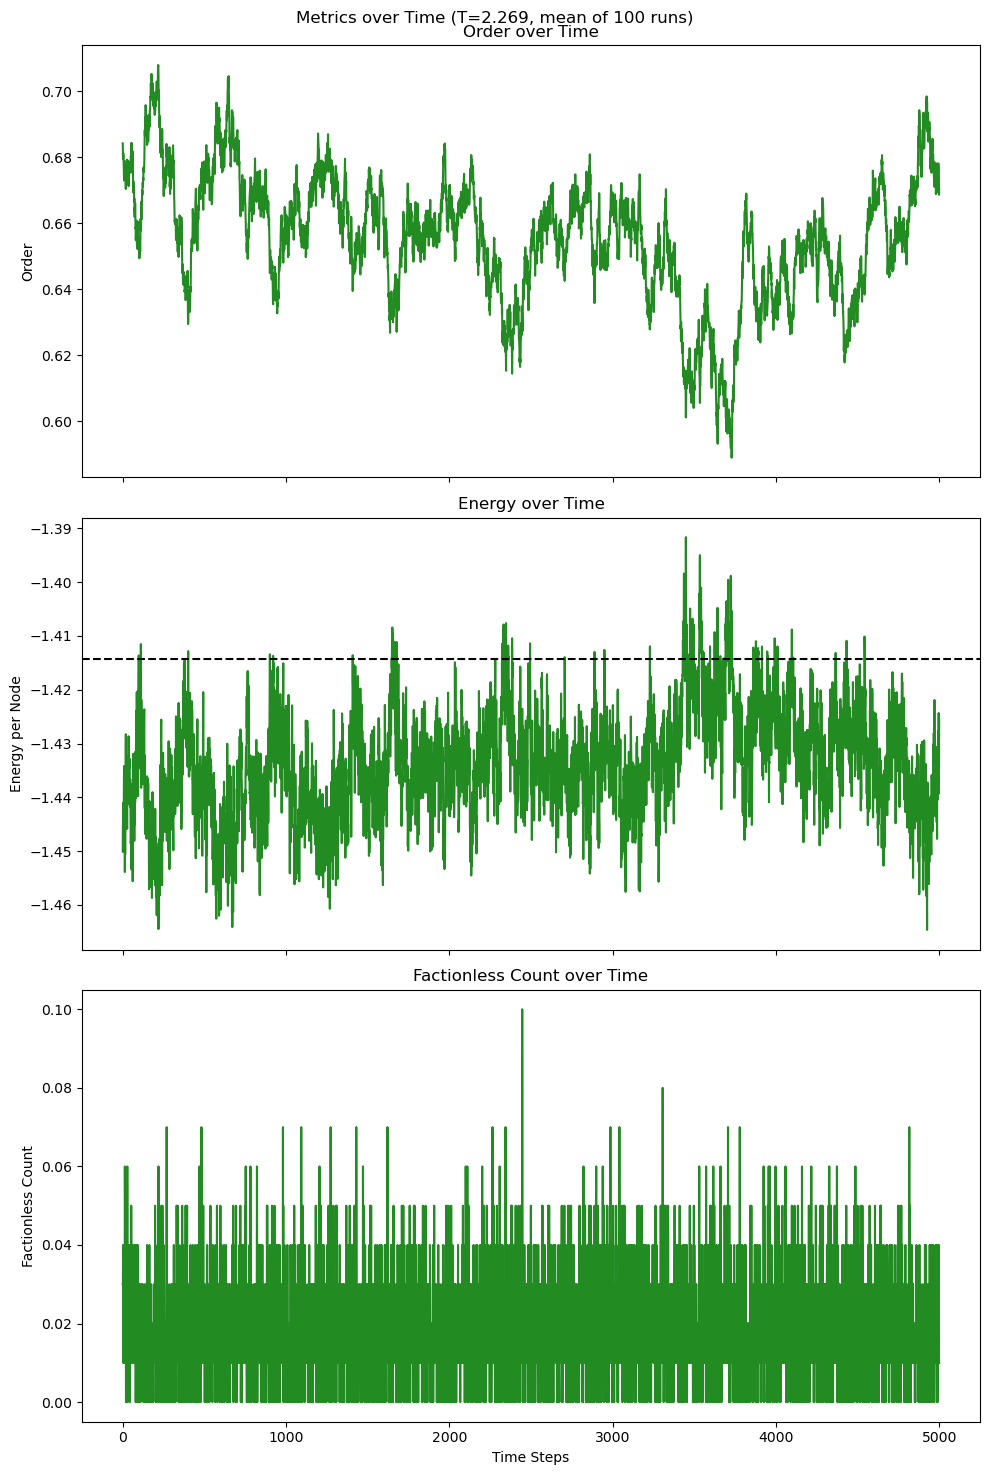

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
# axs[0].plot(orders.T, alpha=0.2, color='forestgreen')
fig.suptitle(f'Metrics over Time (T={ISING_T_C}, mean of {n_runs} runs)')
axs[0].plot(mean_abs_order, color='forestgreen', label='Mean Order')
axs[0].set_title('Order over Time')
axs[0].set_ylabel('Order')
# axs[1].plot(energies.T, alpha=0.05, color='forestgreen')
axs[1].plot(mean_energy, color='forestgreen', label='Mean Energy per Node')
axs[1].set_title('Energy over Time')
axs[1].set_ylabel('Energy per Node')
axs[1].axhline(-np.sqrt(2), color='black', linestyle='--')
# axs[1].set_yscale('symlog')
# axs[2].plot(factionless_counts.T, alpha=0.2, color='forestgreen')
axs[2].plot(mean_factionless, color='forestgreen', label='Mean Factionless Count')
axs[2].set_title('Factionless Count over Time')
axs[2].set_xlabel('Time Steps')
axs[2].set_ylabel('Factionless Count')
# axs[2].set_yscale('log')
plt.tight_layout()
plt.savefig('figures/ising/metrics_over_time.png')
plt.show()

In [ ]:
ISING_T_HIGH = ISING_T_C + 0.1
ISING_T_LOW = ISING_T_C - 0.1
PARAMS_HIGH = ta.TA_Params(adj_matrix=GRID, T=ISING_T_HIGH, h=0.0, theta=1.0, kappa=5.0, seed=SEED)
PARAMS_LOW = ta.TA_Params(adj_matrix=GRID, T=ISING_T_LOW, h=0.0, theta=1.0, kappa=5.0, seed=SEED)
MODEL_HIGH = ta.TerritorialAutomaton(PARAMS_HIGH)
MODEL_LOW = ta.TerritorialAutomaton(PARAMS_LOW)

STORE_HIGH = storage.Store.create(
    'ising_T_high.h5',
    "Exploration of the Ising special case at T > T_C",
    GRID, pos=POS,
    topology_info={'type': 'grid', 'N': L, 'periodic': True},
    base_params={'T': ISING_T_HIGH, 'h': 0.0, 'theta': 1.0, 'kappa': 5.0, 'seed': SEED},
)
STORE_LOW = storage.Store.create(
    'ising_T_low.h5',
    "Exploration of the Ising special case at T < T_C",
    GRID, pos=POS,
    topology_info={'type': 'grid', 'N': L, 'periodic': True},
    base_params={'T': ISING_T_LOW, 'h': 0.0, 'theta': 1.0, 'kappa': 5.0, 'seed': SEED},
)


In [7]:
orders_high = np.zeros((n_runs, length))
orders_low = np.zeros((n_runs, length))

for i in tqdm(range(n_runs)):
    initial_state_high = np.random.choice([ta.STRONG_A, ta.WEAK_A, ta.WEAK_B, ta.STRONG_B], size=L**2)
    result = MODEL_HIGH.run(n_warmup=warmup, n_experiment=length, initial_state=initial_state_high)
    STORE_HIGH.save_run(result, SEED, param_values={'T': ISING_T_HIGH, 'theta': 1.0, 'kappa': 5.0})
    orders_high[i] = result.orders

    initial_state_low = np.random.choice([ta.STRONG_A, ta.WEAK_A, ta.WEAK_B, ta.STRONG_B], size=L**2)
    result = MODEL_LOW.run(n_warmup=warmup, n_experiment=length, initial_state=initial_state_low)
    STORE_LOW.save_run(result, SEED, param_values={'T': ISING_T_LOW, 'theta': 1.0, 'kappa': 5.0})
    orders_low[i] = result.orders

all_orders_high = orders_high.flatten()
all_orders_low = orders_low.flatten()

100%|██████████| 100/100 [08:04<00:00,  4.85s/it]


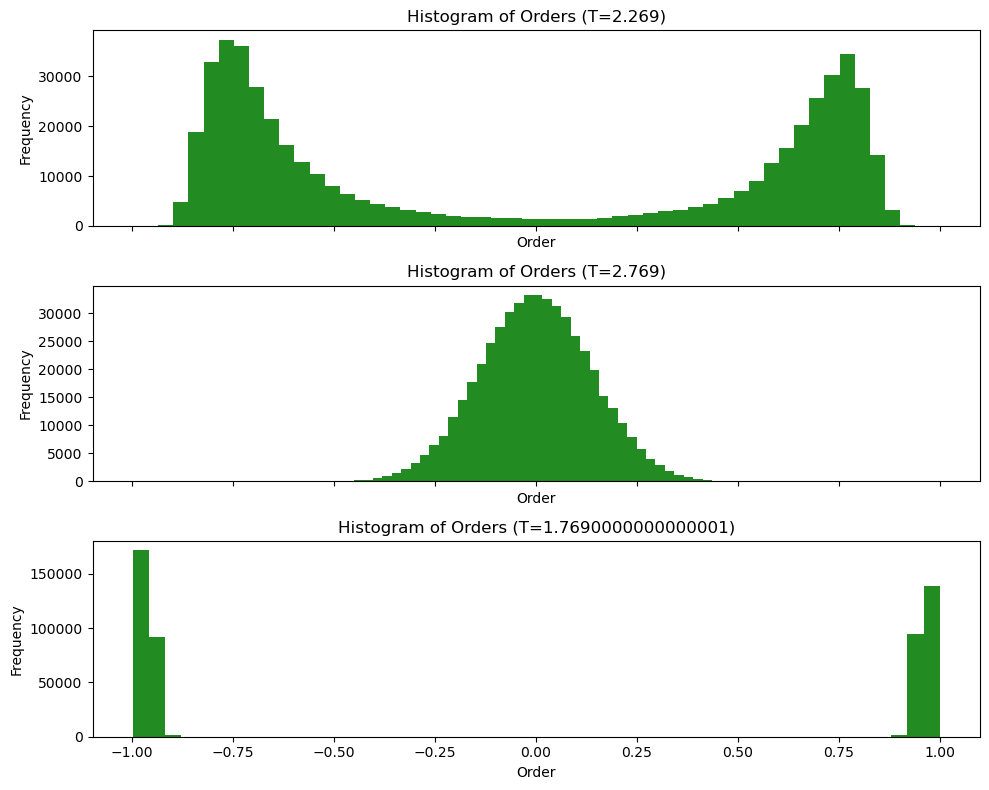

In [8]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].hist(all_orders, bins=50, color='forestgreen')
axs[0].set_title(f'Histogram of Orders (T={ISING_T_C})')
axs[0].set_xlabel('Order')
axs[0].set_ylabel('Frequency')

axs[1].hist(all_orders_high, bins=50, color='forestgreen')
axs[1].set_title(f'Histogram of Orders (T={ISING_T_HIGH})')
axs[1].set_xlabel('Order')
axs[1].set_ylabel('Frequency')

axs[2].hist(all_orders_low, bins=50, color='forestgreen')
axs[2].set_title(f'Histogram of Orders (T={ISING_T_LOW})')
axs[2].set_xlabel('Order')
axs[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('figures/ising/order_histograms.png')

## Sweep over T

In [17]:
num_T = 20
num_runs_per_T = 10
sweep_warmup = 2000
sweep_length = 5000


T_VALUES = np.linspace(ISING_T_C - 0.5, ISING_T_C + 0.5, num_T)

STORE_T_SWEEP = storage.Store.create(
    'ising_T_sweep.h5',
    "Exploration of the Ising special case across a range of T values around T_C",
    GRID, pos=POS,
    topology_info={'type': 'grid', 'N': L, 'periodic': True},
    base_params={'h': 0.0, 'theta': 1.0, 'kappa': 5.0, 'seed': SEED},
)

m = np.zeros((num_T, num_runs_per_T, sweep_length))

for i, T in enumerate(tqdm(T_VALUES)):
    orders = np.zeros((num_runs_per_T, sweep_length))
    PARAMS = ta.TA_Params(adj_matrix=GRID, T=T, h=0.0, theta=1.0, kappa=5.0, seed=SEED)
    MODEL = ta.TerritorialAutomaton(PARAMS)
    for run in range(num_runs_per_T):
        result = MODEL.run(n_warmup=sweep_warmup, n_experiment=sweep_length, initial_state=np.random.choice([ta.STRONG_A, ta.WEAK_A, ta.WEAK_B, ta.STRONG_B], size=L**2))
        STORE_T_SWEEP.save_run(result, SEED, param_values={'T': T, 'theta': 1.0, 'kappa': 5.0})
        m[i, run] = result.orders

m2 = m**2
m4 = m**4

avg_abs_m = np.mean(np.abs(m), axis=(1, 2))
abs_m_se = np.std(np.mean(np.abs(m), axis=2), axis=1, ddof=1) / np.sqrt(num_runs_per_T)

100%|██████████| 20/20 [08:08<00:00, 24.43s/it]


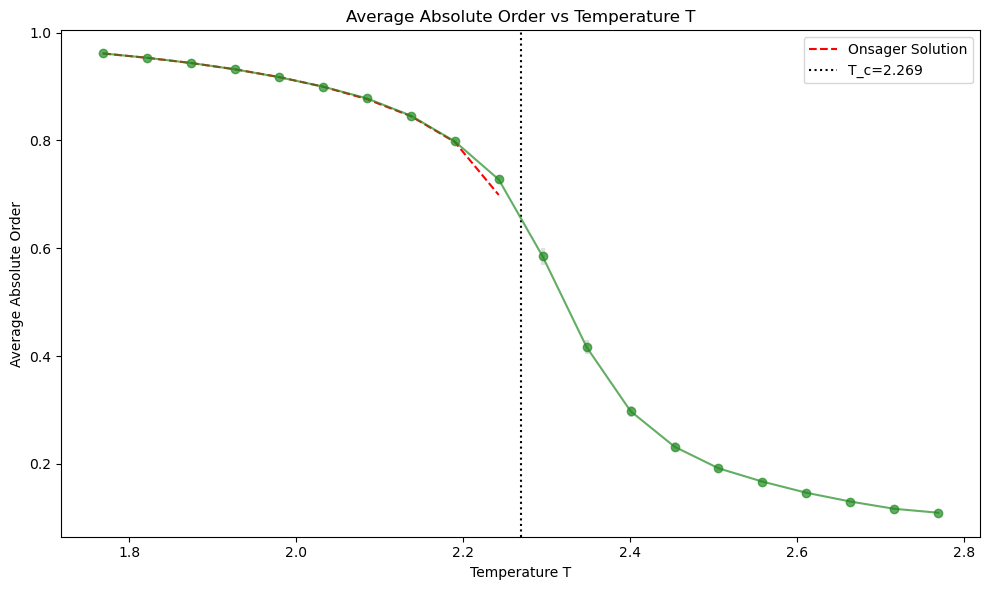

In [26]:
plt.figure(figsize=(10, 6))
plt.errorbar(T_VALUES, avg_abs_m, yerr=abs_m_se, fmt='o-', color='forestgreen', ecolor='lightgray', elinewidth=3, capsize=0, alpha=0.7)
plt.plot(T_VALUES[:num_T//2], (1 - (np.sinh(2/T_VALUES[:num_T//2])**(-4)))**(0.125), color='red', linestyle='--', label='Onsager Solution')
plt.axvline(ISING_T_C, color='black', linestyle=':', label=f'T_c={ISING_T_C:.3f}')
plt.title('Average Absolute Order vs Temperature T')
plt.xlabel('Temperature T')
plt.ylabel('Average Absolute Order')
plt.legend()
plt.tight_layout()
plt.savefig('figures/ising/avg_abs_order_vs_T.png')
plt.show()